<a href="https://colab.research.google.com/github/xvillarreald-max/PROCESAMIENTO-DIGITAL-DE-IMAGENES-Y-LABORATORIO/blob/main/PDIP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROCESAMIENTO DIGITAL DE IMÁGENES Y LABORATORIO

PRÁCTICA 3

Ximena Villarreal Dávila - 2177714

Karen Melisa Morales Moya - 2043909

Andrea Sofía Cantú Trejo - 2120574

Julia Aracely

Parte 1. Clustering de imágenes

In [5]:
#Importamos las librerías necesarias para el código
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Cargar la imagen

Para esta parte solamente utilizamos la librería CV2 para cargar la imagen y pasarla a formato RGB para que después KMeans y Matplotlib puedan leer los colores de manera correcta

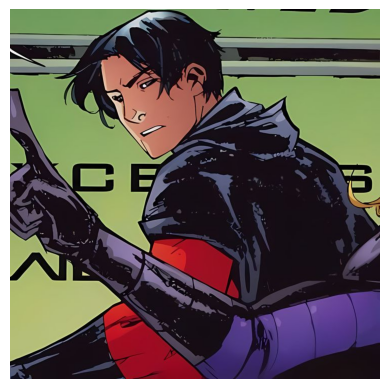

In [6]:
img_bgr = cv2.imread("timdrake.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#para comprobar que si se cargó
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

Ejercicio 1. Mostrar la imagen en el espacio RGB

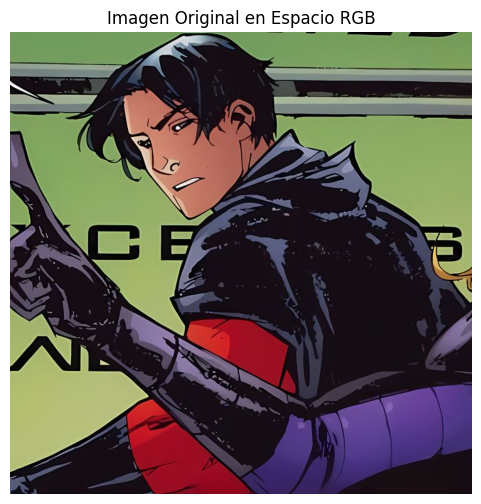

In [7]:
#Mostrar la imagen original
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Imagen Original en Espacio RGB")
plt.axis("off")
plt.show()


Extraer los valores RGB de los pixeles

Esto se hacce ya que KMeans no lee la imagen como tal, sino como una matriz con valores que representan el color al aplicarle esta función se transforma la imagen en una lista con filas equivalentes a cada píxel y 3 columnas [R, G, B]

In [8]:
pixeles = img_rgb.reshape((-1, 3))
print(f"Total de píxeles extraídos: {pixeles.shape[0]}")


Total de píxeles extraídos: 541696


Mostrar un gráfico 3D del espacio RGB

Para que el algoritmo pueda hacer una gráfica identificando los colores que tienen parecido entre sí, debe tomar los valores de los pixeles como puntos dentro de un cubo 3D, por eso se le asigna un color de los del RGB a cada eje de la gráfica, y al tener los pixeles extraidos en formato RGB también, KMeans puede aplicar la distancia  para medir qué tan cerca está un píxel de otro y agrupar los colores similares en el mismo clúster.

In [9]:
pixeles = img_rgb.reshape((-1, 3))
paso = max(1, len(pixeles) // 2000)
muestra_pixeles = pixeles[::paso]

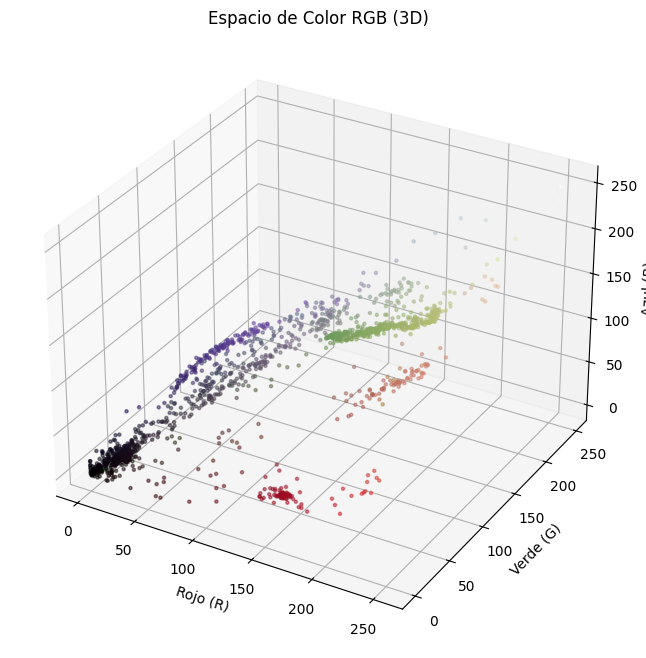

In [10]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
colors = muestra_pixeles / 255.0
ax.scatter(muestra_pixeles[:, 0], muestra_pixeles[:, 1], muestra_pixeles[:, 2], c=colors, marker='.', alpha=0.5)
ax.set_xlabel('Rojo (R)')
ax.set_ylabel('Verde (G)')
ax.set_zlabel('Azul (B)')
ax.set_title('Espacio de Color RGB (3D)')
plt.show()

Ejercicio 2: Segmentación con K-means

Aplicar el algoritmo k-means

Primero preparamos los datos para que KMeans pueda realizar los cálculos, luego aplicamos kmeans con las mismas reglas, para que después asignemos etiquetas a cada pixel, lo que nos dirá a que grupo pertenece.

Luego centros extrae las coordenadas RGB con los promedios de los grupos y los vuelve a convertir en colores válidos

In [11]:
def aplicar_kmeans(pixeles, shape_original, k):
    datos = np.float32(pixeles) # Convertir a float para K-Means

    # Aplicar K-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(datos)
    centros = np.uint8(kmeans.cluster_centers_)

    # Reconstruir la imagen segmentada
    imagen_segmentada = centros[labels].reshape(shape_original)

    return imagen_segmentada, centros

De una vez aplicampos para k= 2, 4, 6

La k nos indica en cuants grupos de collores se va dividir nuestra imagen, en este caso intentaremos con tres diferentes valores para k, esta celda sirve para ejecutar en bucle para los distintos valores de k, mostrar las imagenes y compararlas.

La celda también muestra en texto los valores exactos de cada color (RGB) promedio que encontró el algoritmo para ese nivel de k


Colores promedio de los 2 clusters (RGB):
  Cluster 1: [141 145 113]
  Cluster 2: [37 19 31]

Colores promedio de los 4 clusters (RGB):
  Cluster 1: [20 13 20]
  Cluster 2: [151 163 112]
  Cluster 3: [ 83  71 111]
  Cluster 4: [161  20  35]

Colores promedio de los 6 clusters (RGB):
  Cluster 1: [20 13 20]
  Cluster 2: [176 183 126]
  Cluster 3: [ 77  65 107]
  Cluster 4: [161  18  35]
  Cluster 5: [142 117 123]
  Cluster 6: [134 167  98]


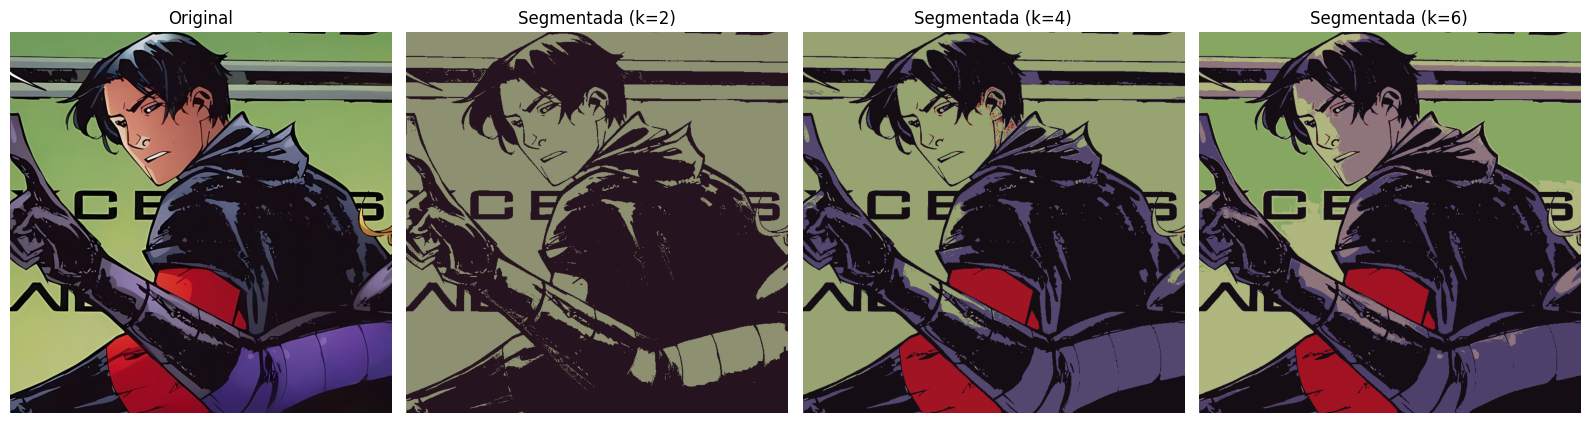

In [12]:
valores_k = [2, 4, 6]
fig, axes = plt.subplots(1, len(valores_k) + 1, figsize=(16, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

for idx, k in enumerate(valores_k):
    img_seg, colores = aplicar_kmeans(pixeles, img_rgb.shape, k)

    # Mostrar la imagen segmentada
    axes[idx + 1].imshow(img_seg)
    axes[idx + 1].set_title(f"Segmentada (k={k})")
    axes[idx + 1].axis("off")

    # Imprimir los colores promedio del cluster en consola
    print(f"\nColores promedio de los {k} clusters (RGB):")
    for c_idx, color in enumerate(colores):
        print(f"  Cluster {c_idx + 1}: {color}")

plt.tight_layout()
plt.show()

Ejercicio 3: Aplicación práctica

De nuevo solamente cargamos la imagen, el ejercicio dice que debe ser una que contenga varios colores y regiones

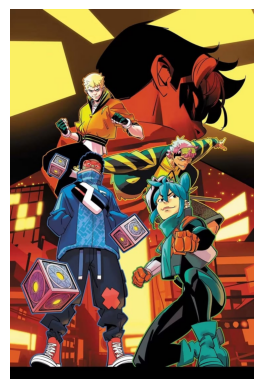

In [13]:
img_bgr = cv2.imread("imagencolorida.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#para comprobar que si se cargó
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

Volvemos a extraer los pixeles y definimos a los pixeles como un tipo de dato float para que el algoritmo pueda hacer los cálculos

In [17]:
pixeles = img_rgb.reshape((-1, 3))
pixeles_float = np.float32(pixeles)

En este caso asigne un valor de k = 5 pero en realidad este valor puede ser modificado, aplicamos el algoritmo de KMeans, otra vez asignamos etiquetas para ver a que grupo pertenece, y con los promedios o cálculos de dicho grupo, podemos volver a transformarlo en un color válido.

In [21]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixeles_float)
centros = np.uint8(kmeans.cluster_centers_)

Se compara la imagen original con la imagen segmentada

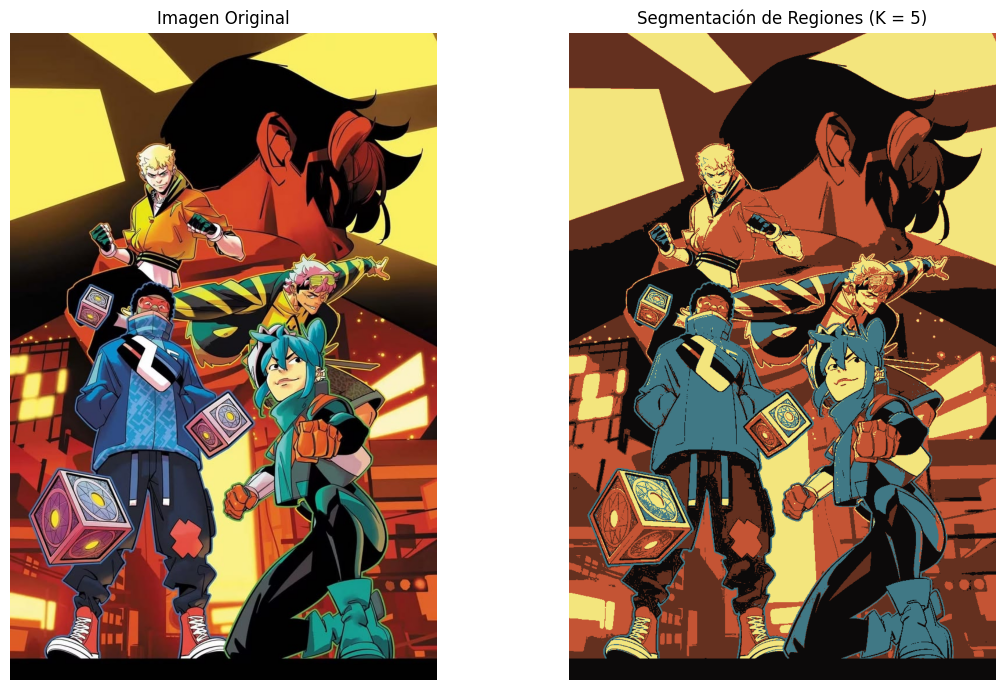

In [23]:
imagen_segmentada = centros[labels].reshape(img_rgb.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

ax1.imshow(img_rgb)
ax1.set_title("Imagen Original")
ax1.axis('off')

ax2.imshow(imagen_segmentada)
ax2.set_title(f"Segmentación de Regiones (K = {k})")
ax2.axis('off')

plt.tight_layout()
plt.show()

Como mencioné anteriormente, la función de centros hace que los valores de los grupos se puedan ver como colores válidos, así que solamente graficamos estos valores para obtener la paleta de colores dominantes.

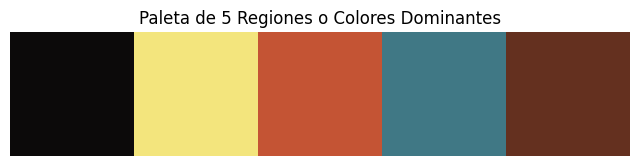

In [25]:
plt.figure(figsize=(8, 2))
plt.imshow([centros])
plt.title(f"Paleta de {k} Regiones o Colores Dominantes")
plt.axis('off')
plt.show()

REFERENCIAS

https://github.com/dilp90/PDI/blob/main/Others/PDI_Clustering.ipynb

https://lesteve.github.io/scikit-learn/stable/auto_examples/cluster/plot_color_quantization.html

https://github.com/opencv/opencv/tree/4.x/doc/py_tutorials/py_ml/py_kmeans

Imágenes utilizadas con derechos reservados pertenecientes a **DC Comics** / **DC Entertainment**. Utilizadas exclusivamente con fines académicos.
